In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, accuracy_score

import numpy as np
import seaborn as sns

In [2]:
# 1. Load the data from the CSV file into a pandas DataFrame
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

print("Original Data:")
print(df.head())
print("-" * 30)

Original Data:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   Na

In [3]:
# categorize
target = 'Survived'
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']

X = df[features]
y = df[target]




In [4]:
# Clean Data
X['Age'].fillna(X['Age'].median(), inplace=True)
X['Embarked'].fillna(X['Embarked'].mode()[0], inplace=True)



/var/folders/x0/dd1k8z7n1vv3hz8l45gqyk9w0000gn/T/ipykernel_61416/3811721166.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(X['Age'].median(), inplace=True)
/var/folders/x0/dd1k8z7n1vv3hz8l45gqyk9w0000gn/T/ipykernel_61416/3811721166.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Age'].fillna(X['Age'].median(), inpla

In [5]:
# One Hot Encoding
X = pd.get_dummies(X, columns=['Sex', 'Embarked'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Split Training and Test Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
print("\n--- Training Model with Default Criterion (Gini) ---")
model_default = DecisionTreeClassifier(random_state=42)
model_default.fit(X_train, y_train)
print("Default model (Gini) trained successfully.")




--- Training Model with Default Criterion (Gini) ---
Default model (Gini) trained successfully.


In [8]:
print("\n--- Training Model with Entropy Criterion ---")
model_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
model_entropy.fit(X_train, y_train)
print("Entropy model trained successfully.")




--- Training Model with Entropy Criterion ---
Entropy model trained successfully.


In [9]:
y_pred_default = model_default.predict(X_test)
y_pred_entropy = model_entropy.predict(X_test)

# Calculate the accuracy of each model.
score_default = accuracy_score(y_test, y_pred_default)
score_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"Default Criterion (Gini) Accuracy: {score_default:.4f}")
print(f"Entropy Criterion Accuracy: {score_entropy:.4f}")





Default Criterion (Gini) Accuracy: 0.7821
Entropy Criterion Accuracy: 0.7933


0.7821229050279329

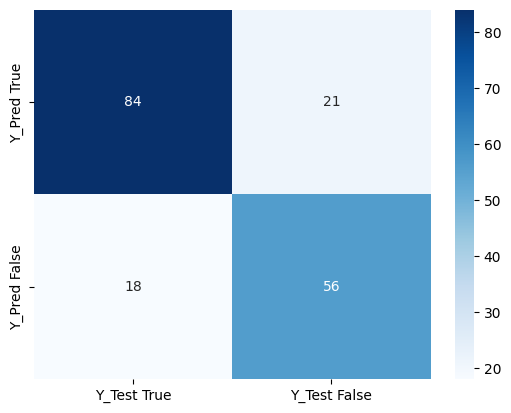

In [10]:



y_pred = model_default.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Y_Test True', 'Y_Test False'], 
            yticklabels=['Y_Pred True', 'Y_Pred False']
           )

model_default.score(X_test, y_test)






0.7932960893854749

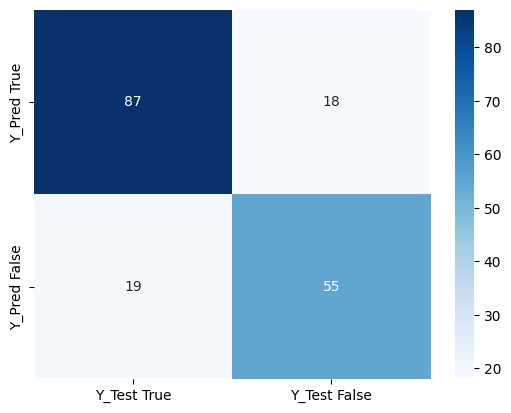

In [11]:

y_pred = model_entropy.predict(X_test)
cm2 = confusion_matrix(y_test, y_pred)


sns.heatmap(cm2, 
            annot=True, 
            fmt='d', 
            cmap='Blues', 
            xticklabels=['Y_Test True', 'Y_Test False'], 
            yticklabels=['Y_Pred True', 'Y_Pred False']
           )

model_entropy.score(X_test, y_test)



In [12]:
new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Age': [25],
    'SibSp': [0],
    'Parch': [0],
    'Fare': [7.25],
    'Sex_male': [1],      # 1 for male, 0 for female
    'Embarked_Q': [0],    # 0 as not Queenstown
    'Embarked_S': [1]     # 1 as Southampton
})
new_passenger = new_passenger[X_train.columns]

# Use the default model to make a prediction
prediction = model_default.predict(new_passenger)
prediction_proba = model_default.predict_proba(new_passenger)
print("\n--- Single Passenger Prediction ---")
print(f"Passenger Data:\n{new_passenger.to_string(index=False)}")
print(f"Predicted Survival: {'Survived' if prediction[0] == 1 else 'Did not survive'}")
print(f"Survival Probability: {prediction_proba[0][1]*100:.2f}%")




--- Single Passenger Prediction ---
Passenger Data:
 Pclass  Age  SibSp  Parch  Fare  Sex_male  Embarked_Q  Embarked_S
      3   25      0      0  7.25         1           0           1
Predicted Survival: Did not survive
Survival Probability: 0.00%
